# Non i.i.d Data
**i.i.d** is independently and identically distributed. It is common to assume that data is i.i.d, meaning the generative process does not have any memory of past samples to generate new samples.

This assumption is usually violated in time series, where each sample can be influenced by previous samples, in an inherently ordered sequence.

To illustrate the issues that arise with cross-validation with non-i.i.d., we load financial data.

In [1]:
import pandas as pd

symbols = {
    "TOT": "Total",
    "XOM": "Exxon",
    "CVX": "Chevron",
    "COP": "ConocoPhillips",
    "VLO": "Valero Energy",
}
template_name = "../{}.csv"

quotes = {}
for symbol in symbols:
    data = pd.read_csv(
        template_name.format(symbol), index_col=0, parse_dates=True
    )
    quotes[symbols[symbol]] = data["open"]
quotes = pd.DataFrame(quotes)

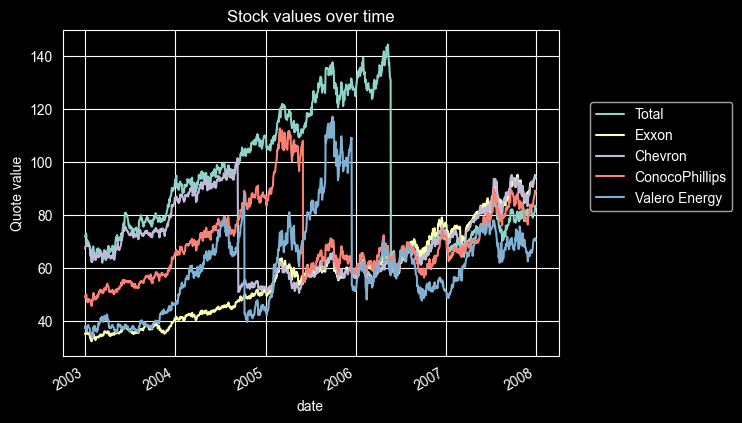

In [2]:
import matplotlib.pyplot as plt

quotes.plot()
plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Stock values over time")

Here, we want to predict the quote of Chevron using all other energy companies' quotes. We will use a decision tree regressor that is expected to overfit and thus will not generalize well to unseen data.

In [3]:
from sklearn.model_selection import train_test_split

data, target = quotes.drop(columns=["Chevron"]), quotes["Chevron"]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

# Shuffling breaks the index order, but we still want it to be time-ordered
data_train.sort_index(ascending=True, inplace=True)
data_test.sort_index(ascending=True, inplace=True)
target_train.sort_index(ascending=True, inplace=True)
target_test.sort_index(ascending=True, inplace=True)

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

regressor = DecisionTreeRegressor()
cv = ShuffleSplit(random_state=0)
test_score = cross_val_score(
    regressor, data_train, target_train, cv=cv, n_jobs=2
)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: 0.89 ± 0.09


Surprisingly, the generalization performance is very good. We will investigate to find the reason for this, as this model is expected to fail.

`ShuffleSplit` is a method that iteratively shuffles and splits the data. We can simplify the procedure with a single split and plot the prediction.

In [5]:
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [6]:
from sklearn.metrics import r2_score

test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: 0.83


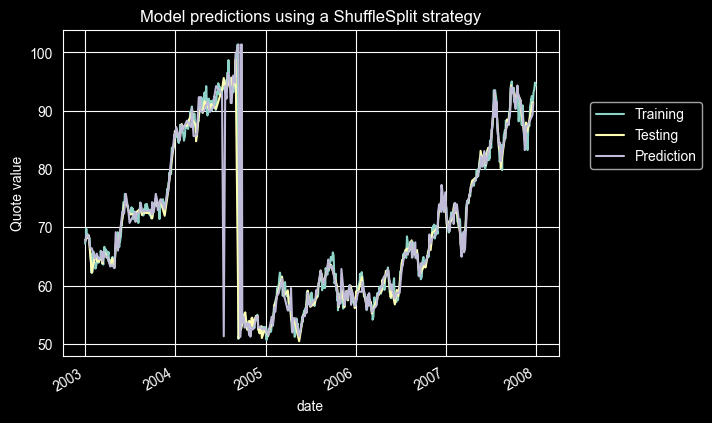

In [7]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a ShuffleSplit strategy")

The result here is a form of **data leakage**, such that the model has gained access to future information while training (testing data), leading to an over-optimistic estimate of the generalization performance.

In theory, for a time series analysis we should be holding out data past a certain point in time for testing. Otherwise, the model is simply getting shuffled results from the entire time series, which makes this model useless.

Instead, we can do a simple 75/25 split with no shuffling.

In [8]:
data_train, data_test, target_train, target_test = train_test_split(
    data,
    target,
    shuffle=False,
    random_state=0,
)
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [9]:
test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: -2.21


As can be seen, a negative $R^2$ indicates that the regressor performs worse than *always predicting the mean of the target*.

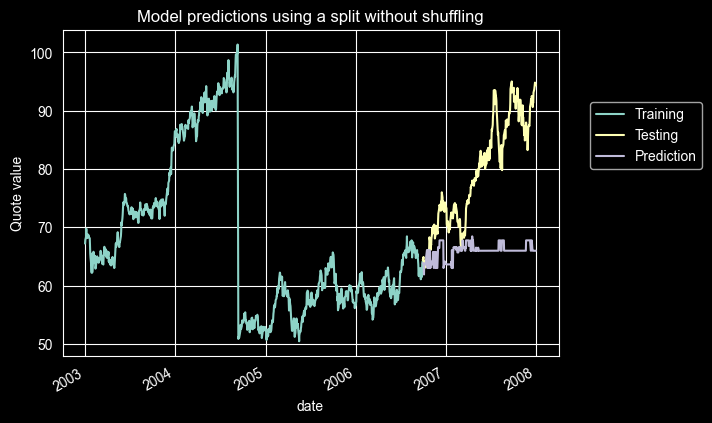

In [10]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a split without shuffling")

The model cannot predict anything because it does not have samples around the testing sample. There are some different approaches we can take to solve this.

One approach is to group the samples into time blocks (for example, by quarter), and predict each group's information by using information from the other groups.

In [11]:
from sklearn.model_selection import LeaveOneGroupOut

groups = quotes.index.to_period("Q")
cv = LeaveOneGroupOut()
test_score = cross_val_score(
    regressor, data, target, cv=cv, groups=groups, n_jobs=2
)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: -0.75 ± 1.67


If our model is aimed at forecasting, we should not use training data that are ulterior to testing data. `TimeSeriesSplit` cross-validation enforces this behaviour.

In [12]:
from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=groups.nunique())
test_score = cross_val_score(regressor, data, target, cv=cv, n_jobs=2)
print(f"The mean R2 is: {test_score.mean():.2f} ± {test_score.std():.2f}")

The mean R2 is: -122.20 ± 511.04
